<a href="https://colab.research.google.com/github/ramakant-BIM/JSW-Projects/blob/main/Behavioral_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

df = pd.read_excel("Behavioral_Analytics_Data.xlsx")

# Print DataFrame columns to help diagnose KeyError
print("DataFrame columns:", df.columns.tolist())

features = [
'BV',
'PF',
'PC',
'SKU',
'Trust',
'Mod',
'Shelf',
'Claim'
]

X = df[features]

y = df['PI']

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

model = RandomForestRegressor(
n_estimators=300,
random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2:",r2_score(y_test,pred))

DataFrame columns: ['ID', 'Type', 'Brand', 'Segment', 'BV', 'PF', 'PC', 'SKU', 'Trust', 'Mod', 'Shelf', 'Claim', 'PI', 'RL', 'Recall']
R2: -0.01903174799258789


In [8]:
importance = pd.DataFrame(
{
'Feature':features,
'Importance':model.feature_importances_
}
)

importance = importance.sort_values(
'Importance',
ascending=False
)

print(importance)

  Feature  Importance
7   Claim    0.145932
4   Trust    0.137469
5     Mod    0.133836
0      BV    0.123196
6   Shelf    0.121875
2      PC    0.116148
1      PF    0.113034
3     SKU    0.108511


##Trust Predictor

In [13]:
Trust = [
'Product_Clarity',
'Claim_Clarity',
'SKU_Clarity',
'Brand_Visibility'
]

##Premium Perception model

In [10]:
X = df[
[
'BV',
'PC',
'SKU',
'Mod',
'Shelf',
'Claim'
]
]

y = df['PF']

##Consumer segmentation

In [18]:
from sklearn.cluster import KMeans

cluster_features = df[
[
'PF',
'Trust',
'PI',
'Mod'
]
]

kmeans = KMeans(
n_clusters=5,
random_state=42
)

df['Cluster'] = kmeans.fit_predict(
cluster_features
)

In [23]:
# Define a mapping for cluster names (adjust these names based on your cluster analysis)
cluster_name_map = {
    0: 'Luxury',
    1: 'Premium',
    2: 'Value Product',
    3: 'Economic',
    4: 'Super Luxury'
}

# Apply the mapping to create a new 'Cluster_Name' column
df['Cluster_Name'] = df['Cluster'].map(cluster_name_map)

# Display the count of each new cluster name to verify
print(df['Cluster_Name'].value_counts())

# Also ensure the order of categories for consistent plotting (optional but good practice)
df['Cluster_Name'] = pd.Categorical(df['Cluster_Name'], categories=list(cluster_name_map.values()), ordered=True)

Cluster_Name
Premium          46
Luxury           35
Value Product    33
Super Luxury     33
Economic         32
Name: count, dtype: int64


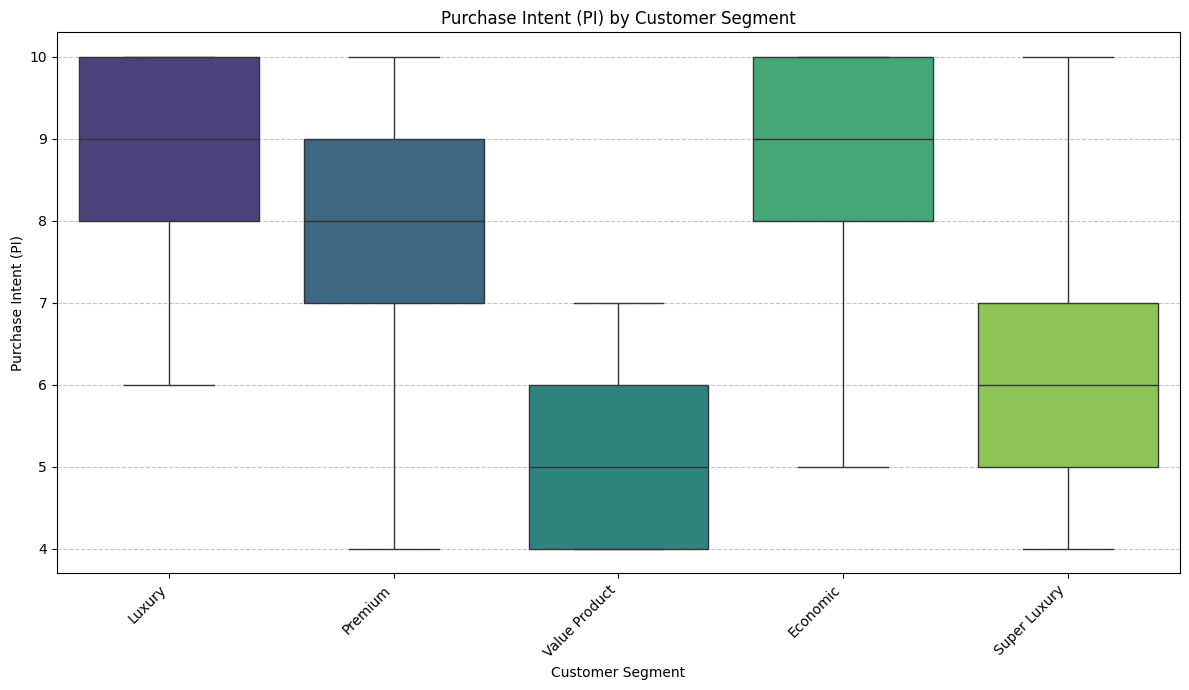

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='Cluster_Name', y='PI', data=df, palette='viridis', hue='Cluster_Name', legend=False)
plt.title('Purchase Intent (PI) by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Purchase Intent (PI)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

### Elbow Method for Optimal K

To determine the optimal number of clusters ($k$), we often use the elbow method. This method plots the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow' point in the graph, where the rate of decrease in WCSS significantly slows down, suggests a suitable number of clusters.

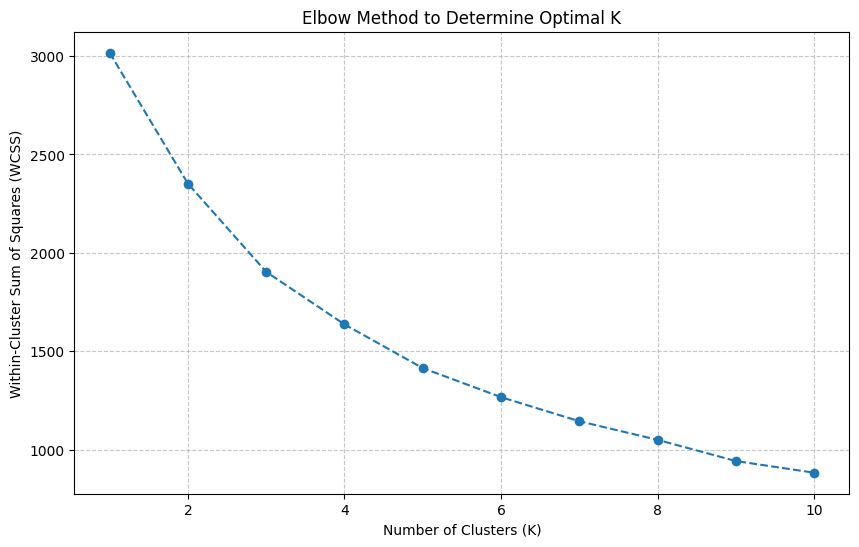

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Assuming 'cluster_features' DataFrame is already defined and contains the features for clustering
# If not, ensure it's defined like: cluster_features = df[['PF', 'Trust', 'PI', 'Mod']]

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init for robustness
    kmeans.fit(cluster_features)
    wcss.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Centroid Chart: Cluster Feature Averages

This chart visualizes the average values of the features used for clustering for each customer segment. This helps in understanding the defining characteristics of each segment.

### Clustering Bubble Chart

This bubble chart visualizes the customer segments based on their average 'Trust' (x-axis), 'Purchase Intent (PI)' (y-axis), and 'Premium Factor (PF)' (bubble size). Each bubble represents a segment, with its color identifying the cluster name. This chart helps to quickly spot segments that are, for example, high in trust and PI, but differ in their premium factor.

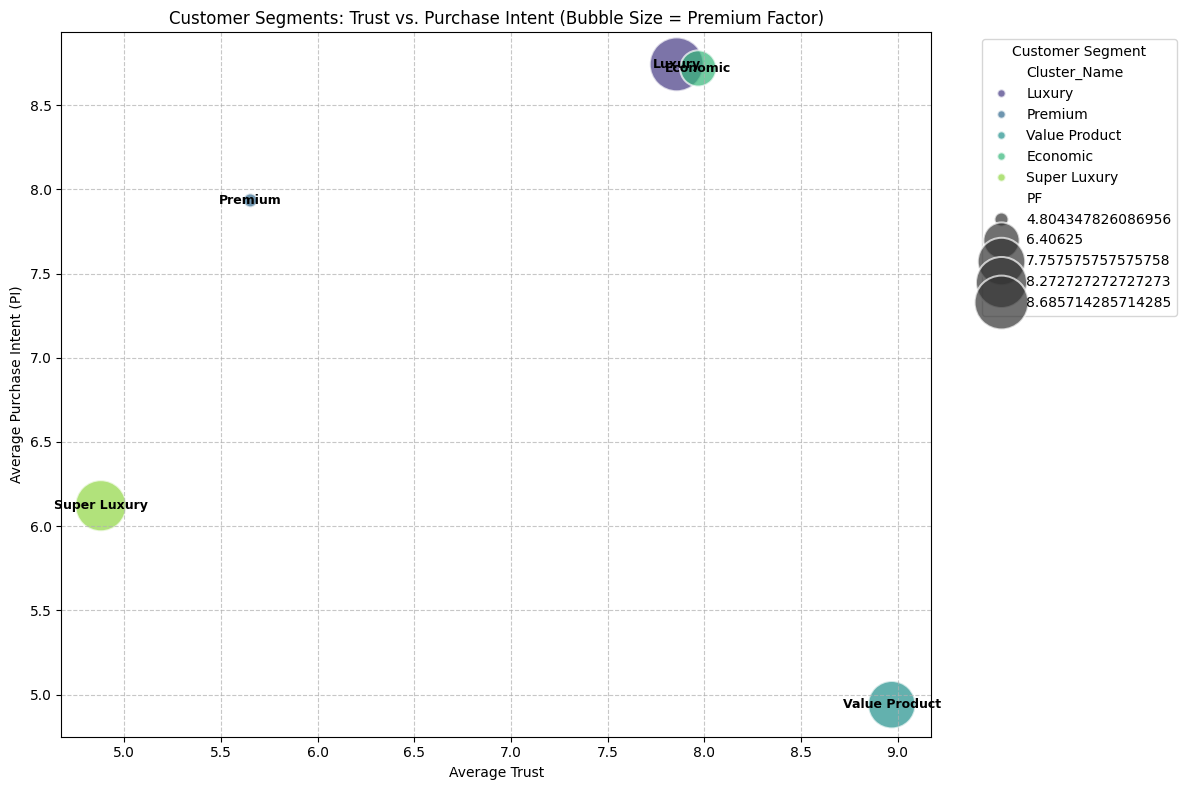

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the mean of key features for each cluster
bubble_chart_data = df.groupby('Cluster_Name', observed=False)[['Trust', 'PI', 'PF']].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=bubble_chart_data,
    x='Trust',
    y='PI',
    size='PF', # Use 'PF' to determine the size of the bubbles
    hue='Cluster_Name', # Color the bubbles by cluster name
    sizes=(100, 1500), # Define the range of bubble sizes
    alpha=0.7,
    palette='viridis'
)

# Add labels to the bubbles for better readability
for i, row in bubble_chart_data.iterrows():
    plt.text(row['Trust'], row['PI'], row['Cluster_Name'],
             horizontalalignment='center', verticalalignment='center',
             fontsize=9, color='black', weight='bold')

plt.title('Customer Segments: Trust vs. Purchase Intent (Bubble Size = Premium Factor)')
plt.xlabel('Average Trust')
plt.ylabel('Average Purchase Intent (PI)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

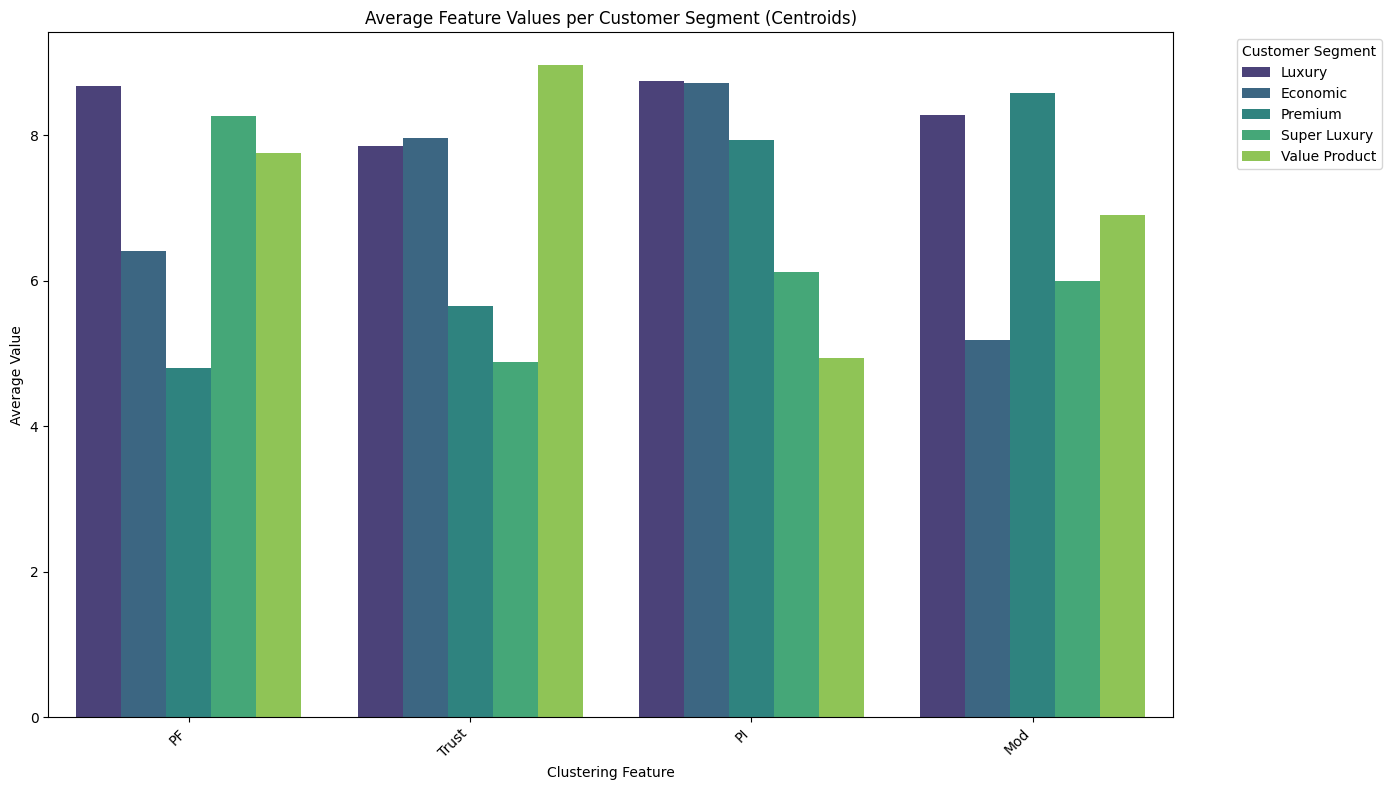

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by the new 'Cluster_Name' and calculate the mean of the original clustering features
cluster_centroids = df.groupby('Cluster_Name', observed=False)[['PF', 'Trust', 'PI', 'Mod']].mean()

# Sort the centroids based on 'PI' for better visualization of intent (optional)
cluster_centroids = cluster_centroids.sort_values(by='PI', ascending=False)

# Transpose for easier plotting (features as x-axis, cluster names as hue)
cluster_centroids_transposed = cluster_centroids.transpose().reset_index()
cluster_centroids_transposed = cluster_centroids_transposed.rename(columns={'index': 'Feature'})

plt.figure(figsize=(14, 8))
sns.barplot(
    x='Feature',
    y='value',
    hue='Cluster_Name',
    data=pd.melt(cluster_centroids_transposed, id_vars=['Feature'], var_name='Cluster_Name'),
    palette='viridis'
)
plt.title('Average Feature Values per Customer Segment (Centroids)')
plt.xlabel('Clustering Feature')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Pair Plot of Clustering Features by Segment

This pair plot visualizes the relationships between all pairs of clustering features ('PF', 'Trust', 'PI', 'Mod'), with data points colored according to their assigned customer segment. This helps in understanding internal correlations within segments and how segments differ across feature distributions.

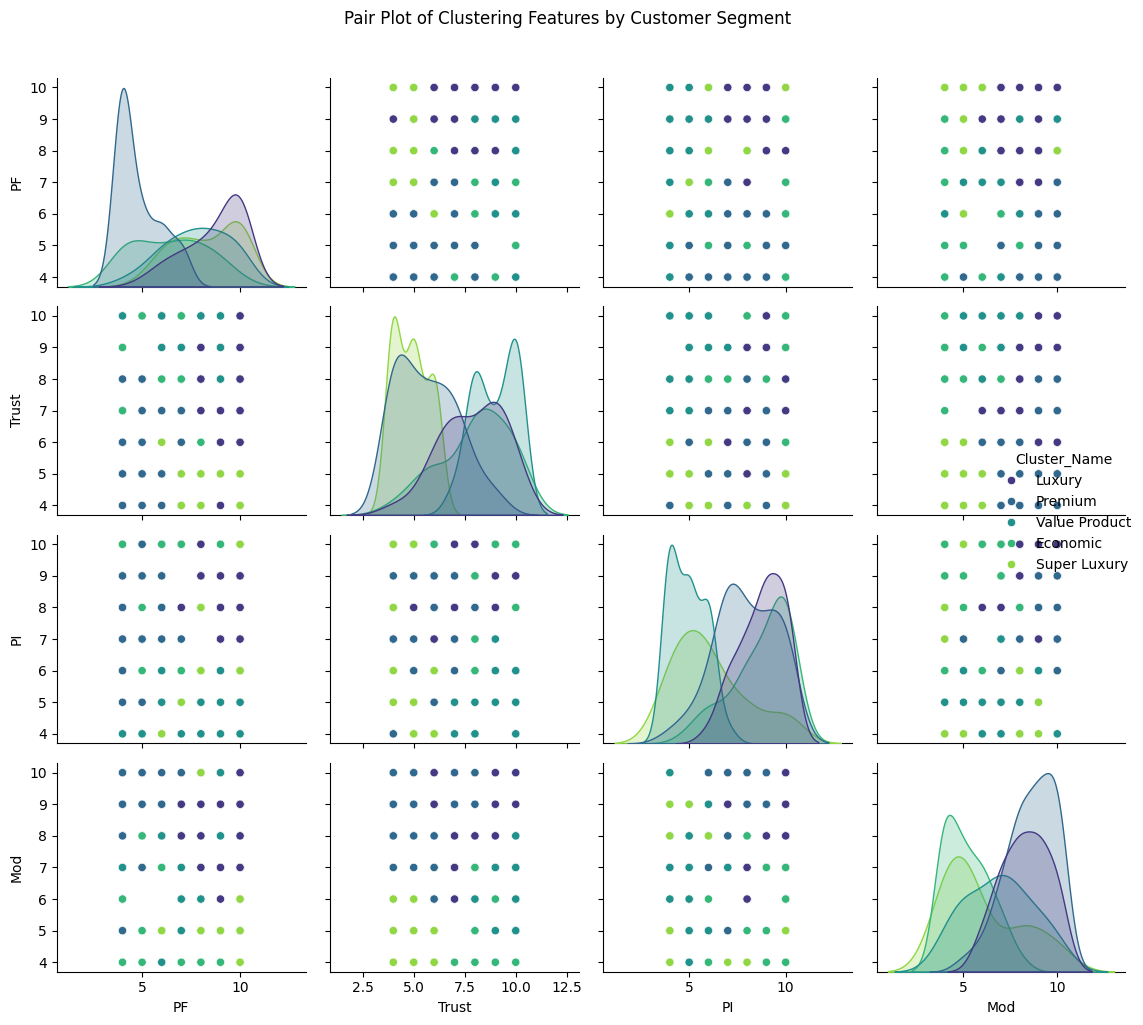

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pair plot colored by 'Cluster_Name'
# We'll use the 'cluster_features' which are 'PF', 'Trust', 'PI', 'Mod'
# and add 'Cluster_Name' to the DataFrame for hue.
plot_df = df[['PF', 'Trust', 'PI', 'Mod', 'Cluster_Name']]

# Set up the PairPlot
# You might want to adjust the `palette` for better visualization if needed
# `diag_kind='kde'` can be used for density plots on the diagonal, or 'hist' for histograms.
fig = sns.pairplot(plot_df, hue='Cluster_Name', palette='viridis', diag_kind='kde', height=2.5)

fig.fig.suptitle('Pair Plot of Clustering Features by Customer Segment', y=1.02) # Adjust title position
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Correlation Heatmap of Numerical Features

This heatmap displays the pairwise correlation coefficients between all numerical features in the dataset. Values range from -1 to 1, where 1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no linear correlation. This helps in identifying highly correlated features, which can be useful for feature selection or understanding relationships between variables.

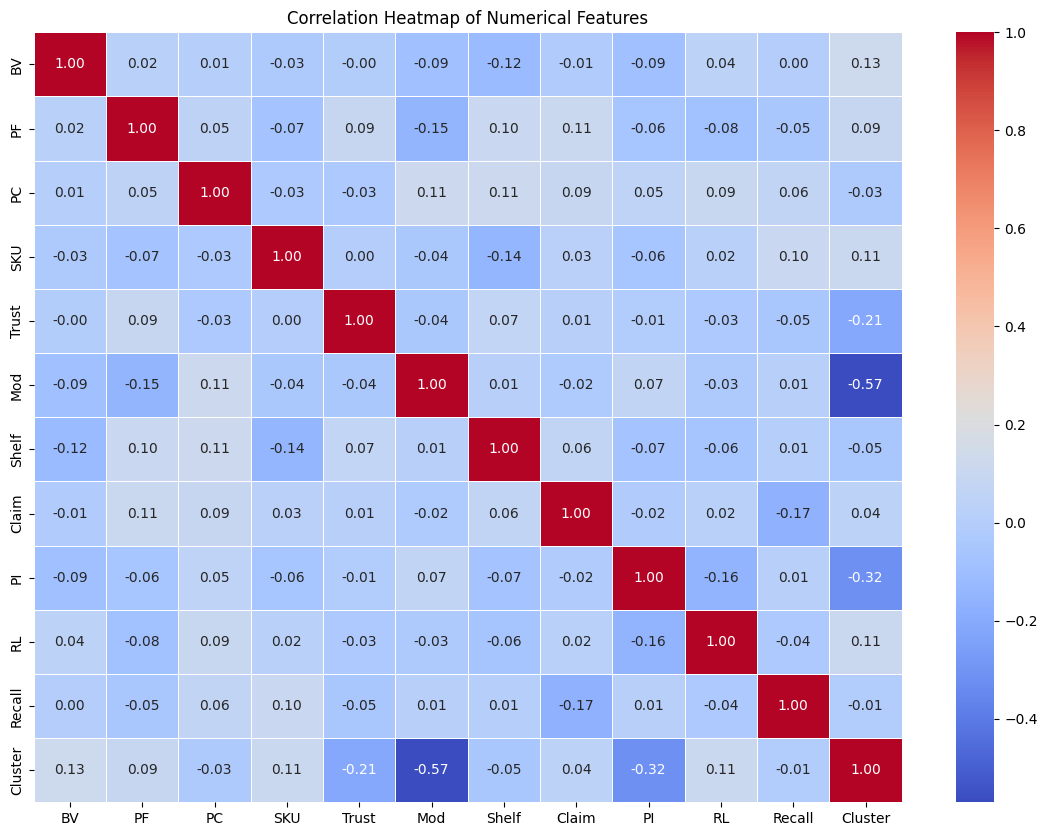

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for the correlation matrix
# Exclude 'ID' as it's typically just an identifier and 'Cluster_Name' which is categorical
numerical_cols = [
    'BV', 'PF', 'PC', 'SKU', 'Trust', 'Mod', 'Shelf', 'Claim', 'PI', 'RL', 'Recall', 'Cluster'
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Brand Distribution per Customer Segment

This analysis visualizes the distribution of different 'Brands' within each identified customer segment. This helps understand brand preferences or market share within specific segments, which is crucial for targeted marketing strategies.

/tmp/ipykernel_1485/3366576734.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_distribution = df.groupby(['Cluster_Name', 'Brand']).size().unstack(fill_value=0)


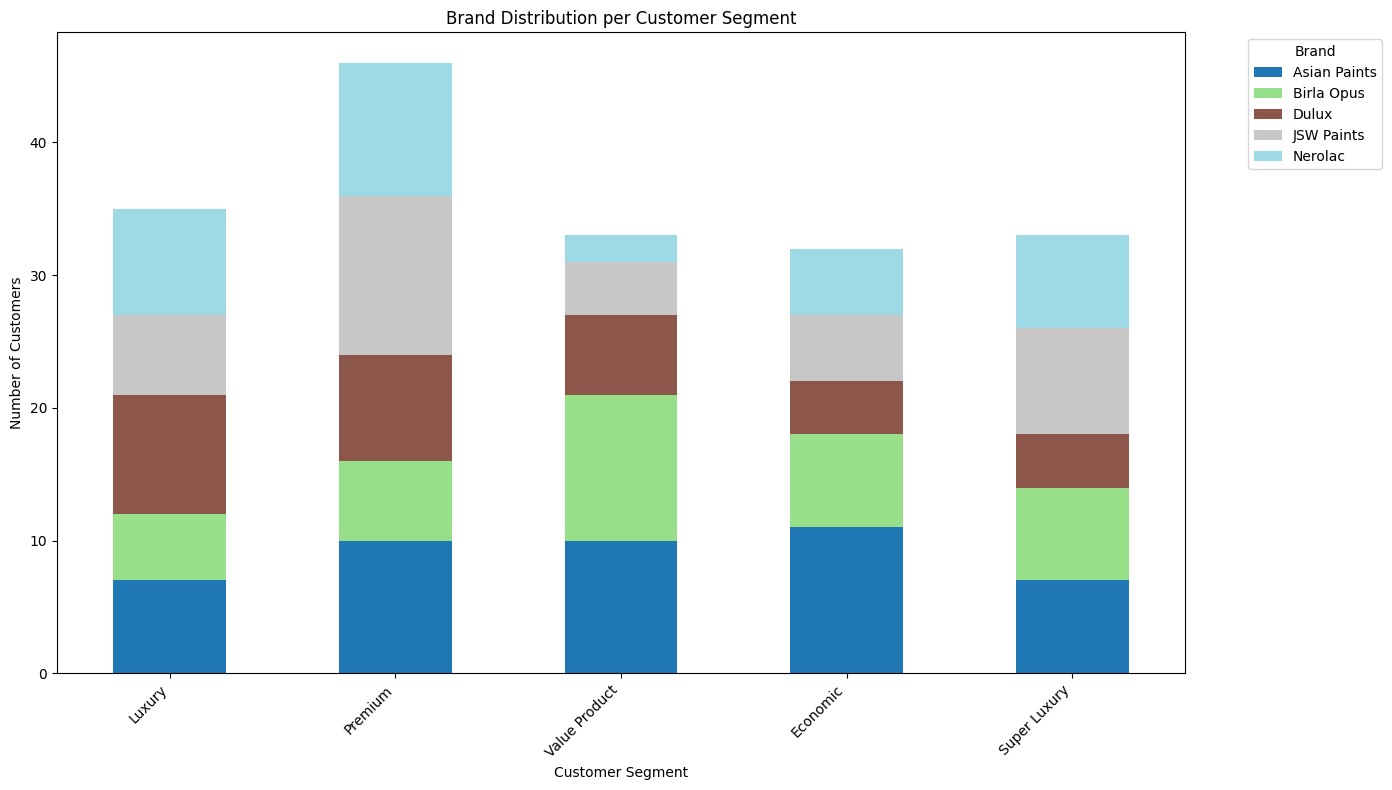

Brand,Asian Paints,Birla Opus,Dulux,JSW Paints,Nerolac
Cluster_Name,,,,,
Luxury,7,5,9,6,8
Premium,10,6,8,12,10
Value Product,10,11,6,4,2
Economic,11,7,4,5,5
Super Luxury,7,7,4,8,7


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the count of each brand within each cluster
brand_distribution = df.groupby(['Cluster_Name', 'Brand']).size().unstack(fill_value=0)

# Plotting the stacked bar chart
brand_distribution.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='tab20')
plt.title('Brand Distribution per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Display the numerical table as well for precise values
display(brand_distribution)

### Type Distribution per Customer Segment

This analysis visualizes the distribution of different 'Types' within each identified customer segment. This helps understand product type preferences or market share within specific segments.

/tmp/ipykernel_1485/1175612883.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_distribution = df.groupby(['Cluster_Name', 'Type']).size().unstack(fill_value=0)


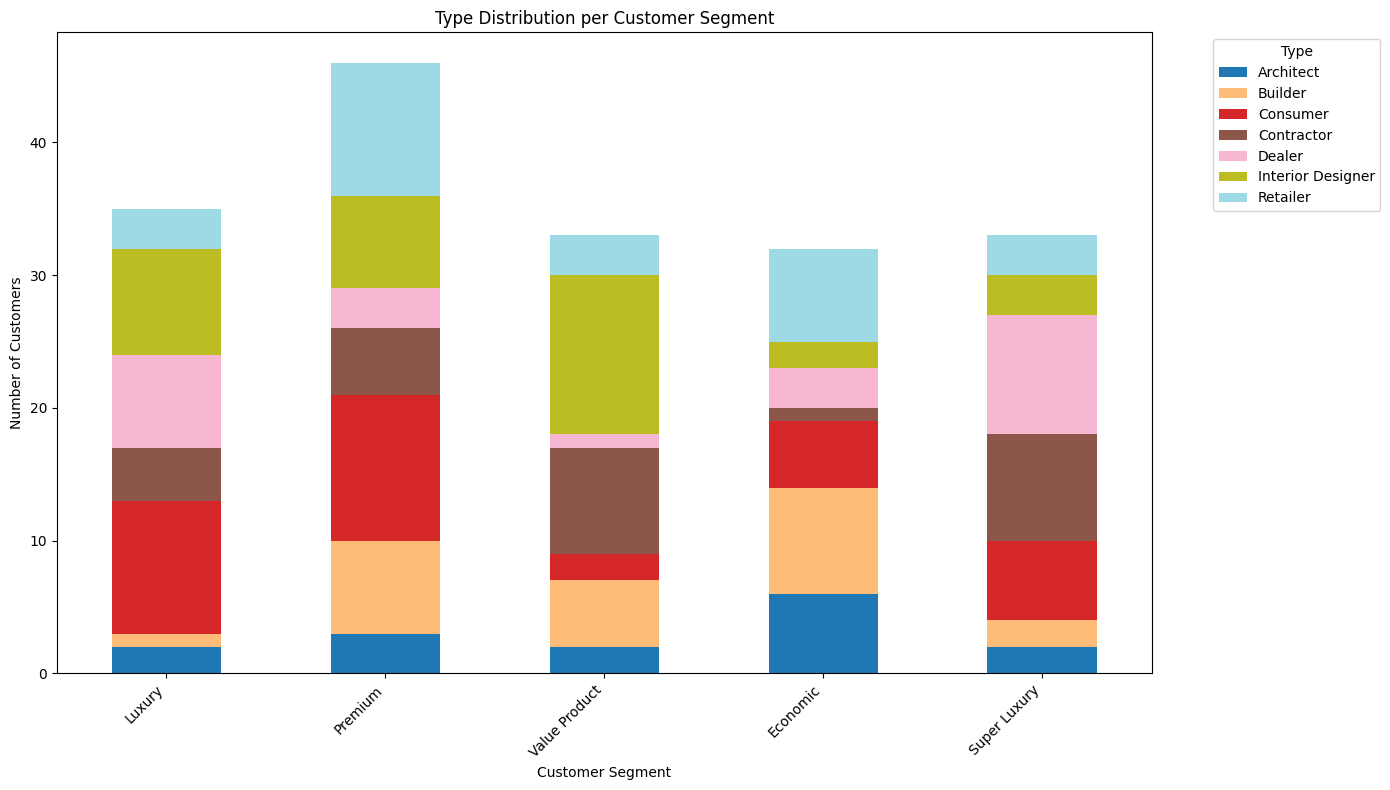

Type,Architect,Builder,Consumer,Contractor,Dealer,Interior Designer,Retailer
Cluster_Name,,,,,,,
Luxury,2,1,10,4,7,8,3
Premium,3,7,11,5,3,7,10
Value Product,2,5,2,8,1,12,3
Economic,6,8,5,1,3,2,7
Super Luxury,2,2,6,8,9,3,3


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the count of each type within each cluster
type_distribution = df.groupby(['Cluster_Name', 'Type']).size().unstack(fill_value=0)

# Plotting the stacked bar chart
type_distribution.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='tab20')
plt.title('Type Distribution per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Display the numerical table as well for precise values
display(type_distribution)